In [1]:
import os
import random
import numpy as np
import librosa
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,ConfusionMatrixDisplay, f1_score, roc_curve)


2026-06-02 07:32:04.333132: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780385524.512877      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780385524.568946      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780385525.005460      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780385525.005505      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780385525.005507      22 computation_placer.cc:177] computation placer alr

In [2]:
import tensorflow as tf


gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {gpus}")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Using GPU: {gpus[0].name}")
else:
    print("No GPU found, running on CPU")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU: /physical_device:GPU:0


# Reconocimiento de audio

In [3]:
SR = 22050
N_FFT = 2048
HOP = 512
N_MELS = 128
MAX_LEN = 128
 
MEL_MATRIX = tf.signal.linear_to_mel_weight_matrix(
    num_mel_bins=N_MELS,
    num_spectrogram_bins=N_FFT // 2 + 1,
    sample_rate=SR,
    lower_edge_hertz=0.0,
    upper_edge_hertz=SR / 2,
)

I0000 00:00:1780385551.040242      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# Creacion de Mel Spectogram

In [4]:
@tf.function(input_signature=[tf.TensorSpec(shape=[None], dtype=tf.float32)])
def tf_mel_spectrogram(waveform):
    stft = tf.signal.stft(
        waveform,
        frame_length=N_FFT,
        frame_step=HOP,
        fft_length=N_FFT,
        window_fn=tf.signal.hann_window,
    )
    power = tf.abs(stft) ** 2
    mel = tf.matmul(power, MEL_MATRIX)
    mel_db = 10.0 * (tf.math.log(mel + 1e-6) / tf.math.log(10.0))
    mel_db = mel_db - tf.reduce_max(mel_db) 
    mel_db = tf.maximum(mel_db, -80.0)
    mel_db = tf.transpose(mel_db)
    frames = tf.shape(mel_db)[1]
    mel_db = tf.cond(
        frames < MAX_LEN,
        lambda: tf.pad(mel_db, [[0, 0], [0, MAX_LEN - frames]],
                       constant_values=-80.0),    
        lambda: mel_db[:, :MAX_LEN],
    )
    mel_db.set_shape([N_MELS, MAX_LEN])
    mel_db = tf.ensure_shape(mel_db, [N_MELS, MAX_LEN])   # returns a tensor, safe to assign
    return mel_db
 
 
def extract_features(path):
    waveform, _ = librosa.load(path, sr=SR, mono=True)
    if waveform.size < HOP:                      # empty or near-empty after silence trim
        raise ValueError("audio too short / empty")
    waveform = tf.convert_to_tensor(waveform, dtype=tf.float32)
    return tf_mel_spectrogram(waveform).numpy()


# Ceacion de divisones test, train, y split usando las divisones del dataset

In [5]:
AUDIO_EXTS = ('.wav', '.mp3', '.flac', '.ogg')
SPLITS = ('training', 'validation', 'testing')

BASE_DIR = '/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-2sec'

def collect_all(base_dir):
    buckets = {s: {'real': [], 'fake': []} for s in SPLITS}
    for dirpath, _, filenames in os.walk(base_dir):
        low = dirpath.lower() + os.sep
        split = next((s for s in SPLITS if os.sep + s + os.sep in low), None)
        if split is None:
            continue
        if os.sep + 'real' + os.sep in low:
            label = 'real'
        elif os.sep + 'fake' + os.sep in low:
            label = 'fake'
        else:
            continue
        for fn in filenames:
            if fn.lower().endswith(AUDIO_EXTS):
                buckets[split][label].append(os.path.join(dirpath, fn))
    return buckets

TARGET_TOTAL = 100_000

buckets = collect_all(BASE_DIR)

groups = [('training','real'), ('training','fake'),
          ('validation','real'), ('validation','fake'),
          ('testing','real'), ('testing','fake')]
total_available = sum(len(buckets[s][l]) for s, l in groups)
fraction = min(1.0, TARGET_TOTAL / total_available)
print(f"Available: {total_available} | target: {TARGET_TOTAL} | fraction: {fraction:.3f}")

rng = random.Random(42)
def take(paths):
    paths = paths[:]
    rng.shuffle(paths)
    return paths[:round(len(paths) * fraction)]

train_real, train_fake = take(buckets['training']['real']),   take(buckets['training']['fake'])
val_real,   val_fake   = take(buckets['validation']['real']), take(buckets['validation']['fake'])
test_real,  test_fake  = take(buckets['testing']['real']),    take(buckets['testing']['fake'])

print(f"Train  real/fake: {len(train_real)}/{len(train_fake)}")
print(f"Val    real/fake: {len(val_real)}/{len(val_fake)}")
print(f"Test   real/fake: {len(test_real)}/{len(test_fake)}")


Available: 17870 | target: 100000 | fraction: 1.000
Train  real/fake: 6978/6978
Val    real/fake: 1413/1413
Test   real/fake: 544/544


In [6]:
feat = extract_features(train_real[0])
print(feat.shape, feat.dtype, float(feat.min()), float(feat.max()))

(128, 128) float32 -80.0 0.0


# Crear array de features por split

In [7]:
def build(real_paths, fake_paths):
    X, y = [], []
    for p in real_paths:
        try:
            X.append(extract_features(p)); y.append(1)   # 1 = real
        except Exception as e:
            print(f"Skipped {p}: {e}")
    for p in fake_paths:
        try:
            X.append(extract_features(p)); y.append(0)   # 0 = fake
        except Exception as e:
            print(f"Skipped {p}: {e}")
    X = np.array(X)[..., np.newaxis]   # (N, 128, 128, 1)  channel axis for Conv2D
    y = np.array(y)
    return X, y
 
 
X_train, y_train = build(train_real, train_fake)
X_val,   y_val   = build(val_real,   val_fake)
X_test,  y_test  = build(test_real,  test_fake)
 
print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")


Train:      (13956, 128, 128, 1)
Validation: (2826, 128, 128, 1)
Test:       (1088, 128, 128, 1)


# Crear data pipeline

In [8]:
STRETCH_MIN, STRETCH_MAX = 0.8, 1.2   # 0.8x–1.2x speed, pitch preserved

def time_warp(spec, label):
    # spec: (N_MELS, MAX_LEN, 1) = (freq, time, 1). Warp TIME only -> pitch unchanged.
    factor = tf.random.uniform([], STRETCH_MIN, STRETCH_MAX)
    new_t = tf.cast(tf.round(tf.cast(MAX_LEN, tf.float32) * factor), tf.int32)
    warped = tf.image.resize(spec, [N_MELS, new_t])        # stretch/compress along time
    def crop():                                            # too long -> center crop
        start = (new_t - MAX_LEN) // 2
        return warped[:, start:start + MAX_LEN, :]
    def pad():                                             # too short -> pad with silence floor
        return tf.pad(warped, [[0, 0], [0, MAX_LEN - new_t], [0, 0]], constant_values=-80.0)
    out = tf.cond(new_t >= MAX_LEN, crop, pad)
    out.set_shape([N_MELS, MAX_LEN, 1])
    return out, label

def make_aug_train_ds(X, y, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), reshuffle_each_iteration=True)
    ds = ds.map(time_warp, num_parallel_calls=AUTOTUNE)    # fresh warp every epoch
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    # NOTE: no .cache() — caching would freeze one warp; we want a new one each epoch

In [9]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
 
 
def make_dataset(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.cache()                              # data fits in RAM
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X))      # reshuffles each epoch
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
 

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)


# Creacion y entrenamiento del modelo

In [10]:
POOLS = 3
F = N_MELS // (2 ** POOLS)
T = MAX_LEN // (2 ** POOLS)
LAST_FILTERS = 128

## Modelo CNN + BiLSTM con 10 capas

### Z normalization

In [11]:
class PerSampleStandardization(layers.Layer):
    def call(self, x):
        mean = tf.reduce_mean(x, axis=[1, 2, 3], keepdims=True)
        std  = tf.math.reduce_std(x, axis=[1, 2, 3], keepdims=True)
        return (x - mean) / (std + 1e-6)

In [12]:
def build_model():
    model = keras.Sequential([
        keras.Input((N_MELS, MAX_LEN, 1)),            # (freq, time, channel)
        PerSampleStandardization(),
        
        # --- CNN 1 ---
        layers.Conv2D(32, 3, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(2),
 
        # --- CNN 2 ---
        layers.Conv2D(64, 3, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(2),
 
        # --- CNN 3 ---
        layers.Conv2D(LAST_FILTERS, 3, padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(2),                        # -> (F, T, LAST_FILTERS)
 
        # --- CNN -> RNN ---
        layers.Permute((2, 1, 3)),                     # -> (time, freq, filters)
        layers.Reshape((T, F * LAST_FILTERS)),         # -> (timesteps=T, features)
 
        # --- BiLSTM sobre el tiempo ---
        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.Bidirectional(layers.LSTM(32)),
 
        # --- clasificador ---
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),         # 1 = real, 0 = fake
    ])
    return model
 
 
model = build_model()
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=["accuracy",
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall"),
             keras.metrics.AUC(name="auc")],
)
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ per_sample_standardization      │ (None, 128, 128, 1)    │             0 │
│ (PerSampleStandardization)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 16, 128)        │     1,081,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,220,865 (4.66 MB)

 Trainable params: 1,220,417 (4.66 MB)

 Non-trainable params: 448 (1.75 KB)

## Pesos de clase para arregla desbalance en el dataset

In [13]:
classes, counts = np.unique(y_train, return_counts=True)
total = counts.sum()
class_weight = {int(c): float(total / (len(classes) * n)) for c, n in zip(classes, counts)}
print("class_weight:", class_weight)

class_weight: {0: 1.0, 1: 1.0}


## Entrenamiento


In [14]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "checkpoint_{epoch}.keras")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_prefix,
        save_weights_only=False,
        save_freq="epoch",
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max",
        patience=5, restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-5,
    ),
]
 
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/40


I0000 00:00:1780385825.221812      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


437/437 ━━━━━━━━━━━━━━━━━━━━ 29s 43ms/step - accuracy: 0.8576 - auc: 0.9270 - loss: 0.3228 - precision: 0.8477 - recall: 0.8774 - val_accuracy: 0.6950 - val_auc: 0.9561 - val_loss: 1.0117 - val_precision: 0.6212 - val_recall: 0.9993 - learning_rate: 1.0000e-04
Epoch 2/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.9880 - auc: 0.9984 - loss: 0.0395 - precision: 0.9886 - recall: 0.9872 - val_accuracy: 0.9901 - val_auc: 0.9978 - val_loss: 0.0389 - val_precision: 1.0000 - val_recall: 0.9802 - learning_rate: 1.0000e-04
Epoch 3/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.9780 - auc: 0.9931 - loss: 0.0719 - precision: 0.9817 - recall: 0.9738 - val_accuracy: 0.9979 - val_auc: 0.9985 - val_loss: 0.0108 - val_precision: 0.9986 - val_recall: 0.9972 - learning_rate: 1.0000e-04
Epoch 4/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.9982 - auc: 0.9999 - loss: 0.0076 - precision: 0.9985 - recall: 0.9979 - val_accuracy: 0.9979 - val_auc: 0.9993 - val_loss: 0.0

# Evaluacion del modelo

In [15]:
test_metrics = model.evaluate(test_ds, return_dict=True)
print("Test:", test_metrics)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8316 - auc: 0.2765 - loss: 1.3516 - precision: 0.8327 - recall: 0.9959
Test: {'accuracy': 0.5110294222831726, 'auc': 0.5386738777160645, 'loss': 3.950979232788086, 'precision': 0.5055969953536987, 'recall': 0.9963235259056091}


## Loss por epoca

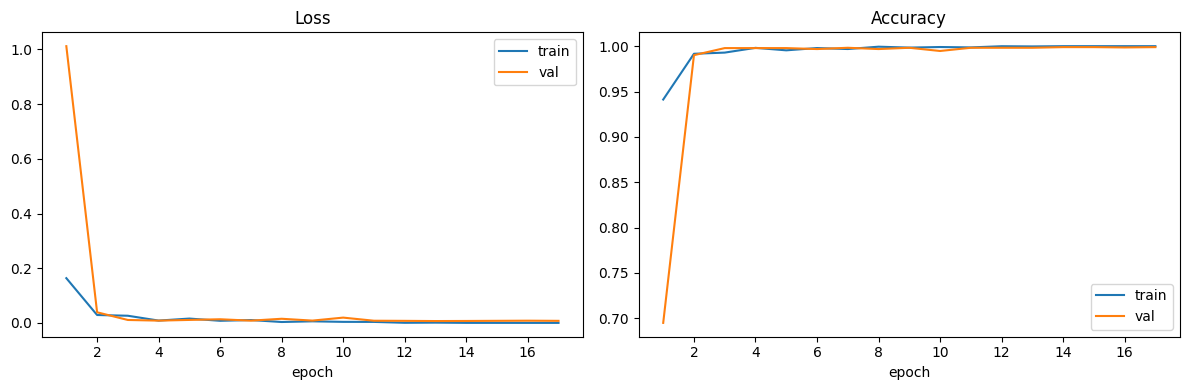

In [16]:
h = history.history
epochs = range(1, len(h["loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epochs, h["loss"], label="train")
ax[0].plot(epochs, h["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(epochs, h["accuracy"], label="train")
ax[1].plot(epochs, h["val_accuracy"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## Predicciones

In [17]:
y_true = np.concatenate([y.numpy() for _, y in test_ds]).astype(int)
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


## Precision / recall / F1 / accuracy

In [18]:
print(classification_report(y_true, y_pred, target_names=["fake (0)", "real (1)"], digits=4))
print(f"Macro F1: {f1_score(y_true, y_pred, average='macro'):.4f}")

              precision    recall  f1-score   support

    fake (0)     0.8750    0.0257    0.0500       544
    real (1)     0.5056    0.9963    0.6708       544

    accuracy                         0.5110      1088
   macro avg     0.6903    0.5110    0.3604      1088
weighted avg     0.6903    0.5110    0.3604      1088

Macro F1: 0.3604


In [19]:
ths = np.linspace(0.0, 1.0, 1001)
f1s = [f1_score(y_true, (y_prob >= t).astype(int), average="macro") for t in ths]
best_t = ths[int(np.argmax(f1s))]
print(f"Best threshold: {best_t:.4f} | macro-F1 there: {max(f1s):.4f}")

fpr, tpr, thr = roc_curve(y_true, y_prob)
fnr = 1 - tpr
i = np.nanargmin(np.abs(fnr - fpr))
print(f"EER: {(fpr[i]+fnr[i])/2:.4f} at threshold {thr[i]:.4f}")

print(classification_report(y_true, (y_prob >= best_t).astype(int),
                            target_names=["fake (0)", "real (1)"], digits=4))

Best threshold: 0.9990 | macro-F1 there: 0.4946
EER: 0.2996 at threshold 0.9999
              precision    recall  f1-score   support

    fake (0)     0.8509    0.1783    0.2948       544
    real (1)     0.5411    0.9688    0.6943       544

    accuracy                         0.5735      1088
   macro avg     0.6960    0.5735    0.4946      1088
weighted avg     0.6960    0.5735    0.4946      1088



## Matriz de confusion

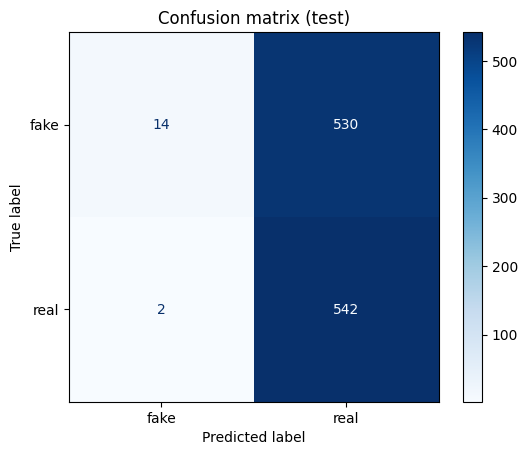

In [20]:
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["fake", "real"]).plot(
    cmap="Blues", values_format="d")
plt.title("Confusion matrix (test)")
plt.show()